In [6]:
import sys
import os
import glob
import gymnasium as gym
from stable_baselines3 import DQN
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from environment.shared_core_config import make_env
from src.utils.evaluate import evaluate_policy

c:\Users\clemm\miniconda3\envs\project-rl-env\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [7]:
sb3_npy_files = glob.glob("../results/sb3/sb3_seed_*_rewards.npy")
sb3_rewards_all = []

for f in sb3_npy_files:
    if os.path.exists(f):
        data = np.load(f)
        sb3_rewards_all.append(data)

if not sb3_rewards_all:
    print("Warning: No SB3 training reward files found in ../results/sb3/")

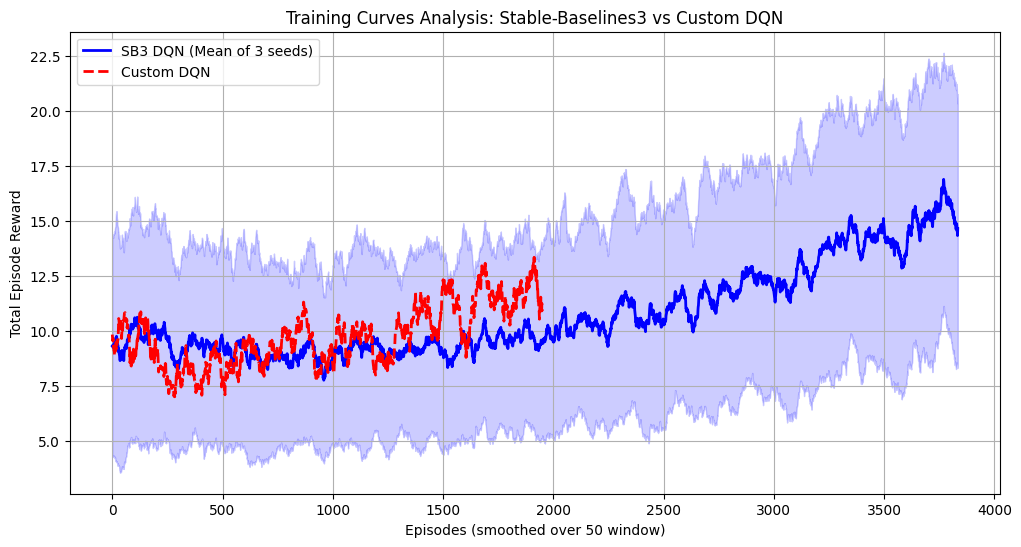

In [ ]:
dqn_file = "../results/dqn_v1_big_buffer_2000_episodes_rewards.npy"
if os.path.exists(dqn_file):
    dqn_rewards = np.load(dqn_file)
else:
    dqn_rewards = None
    print("Warning: Custom DQN reward file not found.")

def moving_average(val, window=50):
    """Calcule une moyenne glissante pour lisser les courbes"""
    if len(val) < window:
        return val
    return np.convolve(val, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 6))


if len(sb3_rewards_all) > 0:
    min_len = min([len(r) for r in sb3_rewards_all])
    sb3_aligned = np.array([r[:min_len] for r in sb3_rewards_all])
    
    sb3_mean = np.mean(sb3_aligned, axis=0)
    sb3_std = np.std(sb3_aligned, axis=0)
    
    sb3_mean_smooth = moving_average(sb3_mean)
    sb3_std_smooth = moving_average(sb3_std)
    x = np.arange(len(sb3_mean_smooth))
    
    plt.plot(x, sb3_mean_smooth, label='SB3 DQN (Mean of 3 seeds)', color='blue', linewidth=2)
    plt.fill_between(x, sb3_mean_smooth - sb3_std_smooth, sb3_mean_smooth + sb3_std_smooth, color='blue', alpha=0.2)

# DQN Custom
if dqn_rewards is not None:
    dqn_smooth = moving_average(dqn_rewards)
    x_dqn = np.arange(len(dqn_smooth))
    plt.plot(x_dqn, dqn_smooth, label='Custom DQN', color='red', linewidth=2, linestyle='--')

plt.title("Training Curves Analysis: Stable-Baselines3 vs Custom DQN")
plt.xlabel("Episodes (smoothed over 50 window)")
plt.ylabel("Total Episode Reward")
plt.legend()
plt.grid(True)
plt.show()